In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


## Initialization

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [4]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 93.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
PATH = "/kaggle/input/competitions/ieee-fraud-detection/"

In [6]:
import mlflow
import dagshub

dagshub.init(repo_owner='ZukaCS', repo_name='ML_assignment_2', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ea57458a-bfdc-491b-8cd8-0f5aad04ae6a&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=0485f8cffda1edd9fa8691598623eb6c0c55f32cc8dce08cfec0bb345a89d5fa




Accessing as ZukaCS

Initialized MLflow to track repo "ZukaCS/ML_assignment_2"

Repository ZukaCS/ML_assignment_2 initialized!

In [7]:
import mlflow
import mlflow.sklearn
import gc
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin


EXPERIMENT_NAME = "RandomForest_Training_v1.1"
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

2026/05/07 08:22:20 INFO mlflow.tracking.fluent: Experiment with name 'RandomForest_Training_v1.1' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow
Experiment: RandomForest_Training_v1.1


In [8]:

train_tx = pd.read_csv(PATH + "train_transaction.csv")
train_id = pd.read_csv(PATH + "train_identity.csv")

train = train_tx.merge(train_id, on="TransactionID", how="left")

print(f"Train shape: {train.shape}")
print(f"Fraud rate: {train['isFraud'].mean():.4f}")

Train shape: (590540, 434)
Fraud rate: 0.0350


In [9]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [14]:
y = train['isFraud']
X = train.drop(columns=['isFraud']) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Train fraud rate: {y_train.mean():.4f}")
print(f"test fraud rate:   {y_test.mean():.4f}")



Train: 472,432 rows | Test: 118,108 rows
Train fraud rate: 0.0350
test fraud rate:   0.0350


# Data cleaning / Preprocessing

In [15]:
class UselessColumnRemover(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop=None):
        self.cols_to_drop = cols_to_drop if cols_to_drop is not None else ['TransactionID']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns],
                      errors='ignore').copy()


In [18]:
class MissingValueHandler(BaseEstimator, TransformerMixin):

    def __init__(self, missing_threshold=0.75):
        self.missing_threshold = missing_threshold
        self.cols_to_drop_ = None
        self.cols_to_flag_ = None

    def fit(self, X, y=None):
        missing_rate = X.isnull().mean()
        self.cols_to_drop_ = missing_rate[missing_rate > self.missing_threshold].index.tolist()
        self.cols_to_flag_ = missing_rate[
            (missing_rate > 0.25) & (missing_rate <= self.missing_threshold)
        ].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols_to_flag_:
            if col in X.columns:
                X[col + '_missing'] = X[col].isnull().astype(np.int8)
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])
        return X

In [19]:
with mlflow.start_run(run_name="RF_Cleaning_Preprocessing"):
    remover = UselessColumnRemover(cols_to_drop=['TransactionID'])
    cleaner = MissingValueHandler(missing_threshold=0.75)
    
    X_train_clean = remover.fit_transform(X_train)
    X_train_clean = cleaner.fit_transform(X_train_clean)
    X_test_clean = remover.transform(X_test)
    X_test_clean = cleaner.transform(X_test_clean)

    mlflow.log_param("dropped_useless_cols", str(remover.cols_to_drop))
    mlflow.log_param("missing_threshold", 0.75)
    mlflow.log_param("mark_missing_interval", "(0.25 to 0.75]")
    mlflow.log_metric("missing_marks_added",  len(cleaner.cols_to_flag_))
    mlflow.log_metric("dropped_missing_cols_count", len(cleaner.cols_to_drop_))
    mlflow.log_metric("remaining_cols_count",       X_train_clean.shape[1])

    print(f"dropped useless cols: {remover.cols_to_drop}")
    print(f"missing marks/ added: {len(cleaner.cols_to_flag_)} cols")
    print(f"Dropped missing cols cnt: {len(cleaner.cols_to_drop_)} cols")
    print(f"Remaining columns cnt: {X_train_clean.shape[1]} cols")

dropped useless cols: ['TransactionID']
missing marks/ added: 44 cols
Dropped missing cols cnt: 208 cols
Remaining columns cnt: 268 cols
🏃 View run RF_Cleaning_Preprocessing at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/6540ff156b674ca8888a3edb4b331c36
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2


# Feature Engineering


In [21]:
class FeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, verbose=True):
        self.user_stats_ = None
        self.verbose = verbose

    def _log(self, msg):
        if self.verbose:
            print(msg)

    def fit(self, X, y=None):
        X = X.copy()
        if 'card1' in X.columns and 'TransactionAmt' in X.columns:
            X['_user_id'] = self._make_user_id(X)
            self.user_stats_ = (
                X.groupby('_user_id')['TransactionAmt']
                 .agg(['count', 'mean', 'std'])
                 .rename(columns={'count': 'user_tr_count',
                                  'mean':  'user_amt_mean',
                                  'std':   'user_amt_standart_dev'})
            )
            self._log(f"Fitted user_stats on {len(self.user_stats_):,} unique users")
        else:
            self._log("Skipping user_stats fit — card1 or TransactionAmt missing")
        return self

    def transform(self, X):
        X = X.copy()
        skipped = []
        added = []

        if 'TransactionAmt' in X.columns:
            X['TransactionAmt_logarithm']   = np.log1p(X['TransactionAmt'])
            X['TransactionAmt_cents'] = X['TransactionAmt'] % 1
            added += ['TransactionAmt_logarithm', 'TransactionAmt_cents']
        else:
            skipped += ['TransactionAmt_logarithm', 'TransactionAmt_cents']

        if 'P_emaildomain' in X.columns and 'R_emaildomain' in X.columns:
            X['email_match'] = (X['P_emaildomain'] == X['R_emaildomain']).astype(np.int8)
            added += ['email_match']
        else:
            skipped += ['email_match']

        if 'TransactionDT' in X.columns:
            X['hour_of_transaction'] = (X['TransactionDT'] // 3600) % 24
            X['day_of_transaction']  = (X['TransactionDT'] // (3600 * 24)) % 7
            added += ['hour_of_transaction', 'day_of_transaction']
        else:
            skipped += ['hour_of_transaction', 'day_of_transaction']

        if 'card1' in X.columns and 'TransactionAmt' in X.columns and self.user_stats_ is not None:
            X['_user_id'] = self._make_user_id(X)
            X = X.join(self.user_stats_, on='_user_id')
            X['user_amt_standart_dev']  = X['user_amt_standart_dev'].fillna(0)
            X['user_amt_zscore'] = (
                (X['TransactionAmt'] - X['user_amt_mean']) /
                X['user_amt_standart_dev'].replace(0, 1)
            ).clip(-5, 5)
            X['user_tr_count_logarithm'] = np.log1p(X['user_tr_count'])
            X = X.drop(columns=['_user_id'])
            added += ['user_tr_count', 'user_amt_mean', 'user_amt_standart_dev',
                      'user_amt_zscore', 'user_tr_count_logarithm']
        else:
            skipped += ['user_tr_count', 'user_amt_mean', 'user_amt_standart_dev',
                        'user_amt_zscore', 'user_tr_count_logarithm']

        self._log(f"Added {len(added)} features: {added}")
        if skipped:
            self._log(f"Skipped {len(skipped)} features (missing source cols): {skipped}")

        return X

    @staticmethod
    def _make_user_id(X):
        return (
            X['card1'].fillna(-1).astype(str) + '_' +
            X.get('card2', pd.Series(-1, index=X.index)).fillna(-1).astype(str) + '_' +
            X.get('addr1', pd.Series(-1, index=X.index)).fillna(-1).astype(str) + '_' +
            X.get('P_emaildomain', pd.Series('unknown', index=X.index)).fillna('unknown').astype(str)
        )

In [22]:
with mlflow.start_run(run_name="RF_Feature_Engineering"):
    fe = FeatureAdder()
    fe.fit(X_train_clean)
    X_train_fe = fe.transform(X_train_clean)
    X_test_fe  = fe.transform(X_test_clean)   
    
    mlflow.log_param("user_id_components", "card1_card2_addr1_P_emaildomain")
    mlflow.log_param("features_added", "log_amt, cents, hour, day, user_aggs (email_match dropped)")
    mlflow.log_metric("n_features_after_FeatureEng", X_train_fe.shape[1])
    print(f"Features after FE: {X_train_fe.shape[1]}")

Fitted user_stats on 82,988 unique users
Added 9 features: ['TransactionAmt_logarithm', 'TransactionAmt_cents', 'hour_of_transaction', 'day_of_transaction', 'user_tr_count', 'user_amt_mean', 'user_amt_standart_dev', 'user_amt_zscore', 'user_tr_count_logarithm']
Skipped 1 features (missing source cols): ['email_match']
Added 9 features: ['TransactionAmt_logarithm', 'TransactionAmt_cents', 'hour_of_transaction', 'day_of_transaction', 'user_tr_count', 'user_amt_mean', 'user_amt_standart_dev', 'user_amt_zscore', 'user_tr_count_logarithm']
Skipped 1 features (missing source cols): ['email_match']
Features after FE: 277
🏃 View run RF_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/d7d151ec254745479b0c28cbf9cbec98
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2


In [23]:
from sklearn.preprocessing import LabelEncoder

class MyCategoricalEncoder(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.encoders_ = {}
        self.cat_cols_ = None

    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include=['object']).columns.tolist()
        for col in self.cat_cols_:
            le = LabelEncoder()
            vals = X[col].fillna('missing').astype(str)
            classes = list(np.unique(vals))
            if 'missing' not in classes:
                classes.append('missing')
            le.classes_ = np.array(sorted(classes))
            self.encoders_[col] = le
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cat_cols_:
            if col in X.columns:
                vals = X[col].fillna('missing').astype(str)
                known = set(self.encoders_[col].classes_)
                vals = vals.apply(lambda v: v if v in known else 'missing')
                X[col] = self.encoders_[col].transform(vals)
        return X



In [24]:
with mlflow.start_run(run_name="RF_Categorical_Encoding"):
    encoder = MyCategoricalEncoder()
    encoder.fit(X_train_fe)
    X_train_enc = encoder.transform(X_train_fe)
    X_test_enc  = encoder.transform(X_test_fe)

    mlflow.log_param("encoding_method", "label_encoding")
    mlflow.log_param("NAN_placeholder", "missing")
    mlflow.log_param("unseen_strategy", "map_to_missing")
    mlflow.log_metric("categorical_cols_count", len(encoder.cat_cols_))
    mlflow.log_metric("features_after_encoding_count", X_train_enc.shape[1])
    mlflow.log_metric("NAN_count_remaining", int(X_train_enc.isnull().sum().sum()))

    print(f"Categorical columns encoded: {len(encoder.cat_cols_)}")
    print(f"Shape after encoding: {X_train_enc.shape}")
    print(f"Object cols left : {len(X_train_enc.select_dtypes(include=['object']).columns)}")
    print(f"total NaN count: {X_train_enc.isnull().sum().sum()}")

Categorical columns encoded: 13
Shape after encoding: (472432, 277)
Object cols left : 0
total NaN count: 10681614
🏃 View run RF_Categorical_Encoding at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/c761235786b8436788942891dfe4368a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2


In [25]:
with mlflow.start_run(run_name="RF_Imputation"):
    imputer_for_selection = SimpleImputer(strategy='median')
    
    X_train_imp = pd.DataFrame(
        imputer_for_selection.fit_transform(X_train_enc),
        columns=X_train_enc.columns,
        index=X_train_enc.index,
    )
    X_test_imp = pd.DataFrame(
        imputer_for_selection.transform(X_test_enc),
        columns=X_test_enc.columns,
        index=X_test_enc.index,
    )
    
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_metric("n_features",         X_train_imp.shape[1])
    mlflow.log_metric("nan_count_before",   int(X_train_enc.isnull().sum().sum()))
    mlflow.log_metric("nan_count_after",    int(X_train_imp.isnull().sum().sum()))
    
    print(f"Imputed: {X_train_enc.isnull().sum().sum():,} NaNs → 0")

Imputed: 10,681,614 NaNs → 0
🏃 View run RF_Imputation at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/920cfabf548641908676f6dd9b7e0ad1
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2


# Feature Selection

In [ ]:
class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.9, sample_size=50_000, random_state=42):
        self.threshold = threshold
        self.sample_size = sample_size
        self.random_state = random_state
        self.features_to_drop_ = None
        self.selected_features_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if self.sample_size and len(X) > self.sample_size:
            X_sample = X.sample(self.sample_size, random_state=self.random_state)
        else:
            X_sample = X

        corr_matrix = X_sample.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.features_to_drop_ = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                partners = upper.index[upper[col] > self.threshold].tolist()
                for partner in partners:
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop_.add(col)
                    else:
                        self.features_to_drop_.add(partner)

        self.selected_features_ = [c for c in X.columns if c not in self.features_to_drop_]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.selected_features_]




In [28]:
from joblib import Parallel, delayed
class IVSelector(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.02, sample_size=50_000, random_state=42, n_jobs=-1):
        self.threshold = threshold
        self.sample_size = sample_size
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.iv_scores_ = {}
        self.selected_features_ = None

    def _compute_iv(self, X, y, col):

        series = X[col].copy()

        if series.nunique() > 10:
            series = pd.qcut(series, q=10, duplicates='drop')

        df = pd.DataFrame({'col': series, 'target': y})
        total_event     = y.sum()
        total_non_event = (1 - y).sum()

        grp = df.groupby('col', observed=True)['target'].agg(['sum', 'count'])
        grp.columns = ['event', 'cnt']
        grp['non_event'] = grp['cnt'] - grp['event']

        dist_event     = (grp['event']     + 0.5) / (total_event     + 0.5)
        dist_non_event = (grp['non_event'] + 0.5) / (total_non_event + 0.5)

        return ((dist_event - dist_non_event) * np.log(dist_event / dist_non_event)).sum()

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        if self.sample_size and len(X) > self.sample_size:
            idx = y.sample(self.sample_size, random_state=self.random_state).index
            X_sample = X.loc[idx].reset_index(drop=True)
            y_sample = y.loc[idx].reset_index(drop=True)
        else:
            X_sample, y_sample = X, y

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._compute_iv)(X_sample, y_sample, col)
            for col in X_sample.columns
        )
        self.iv_scores_ = dict(zip(X_sample.columns, results))
        self.selected_features_ = [c for c, iv in self.iv_scores_.items() if iv >= self.threshold]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.selected_features_]

In [32]:
from sklearn.ensemble import RandomForestClassifier

class TreeImportanceSelector(BaseEstimator, TransformerMixin):
    def __init__(self, top_k=80, n_estimators=50, sample_size=100_000, random_state=42):
        self.top_k = top_k
        self.n_estimators = n_estimators
        self.sample_size = sample_size
        self.random_state = random_state
        self.importances_ = None
        self.selected_features_ = None
    
    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)
        if self.sample_size and len(X) > self.sample_size:
            idx = y.sample(self.sample_size, random_state=self.random_state).index
            X_sample = X.loc[idx].reset_index(drop=True)
            y_sample = y.loc[idx].reset_index(drop=True)
        else:
            X_sample, y_sample = X, y
        rf = RandomForestClassifier(
            n_estimators=self.n_estimators, max_depth=10,
            class_weight='balanced', n_jobs=-1, random_state=self.random_state,
        )
        rf.fit(X_sample, y_sample)
        self.importances_ = pd.Series(rf.feature_importances_, index=X.columns)
        self.selected_features_ = self.importances_.nlargest(self.top_k).index.tolist()
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.selected_features_]

# Training

## Quick baseline test

In [29]:
def quick_rf_eval(X_tr, y_tr, X_va, y_va):
    model = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', n_jobs=-1, random_state=42,
    )
    model.fit(X_tr, y_tr)
    train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_va, model.predict_proba(X_va)[:, 1])
    return train_auc, val_auc


In [33]:
with mlflow.start_run(run_name="RF_Selection_Correlation_baseline"):
    corr_only = CorrelationFilter(threshold=0.9)
    corr_only.fit(X_train_imp)
    X_tr_corr = corr_only.transform(X_train_imp)
    X_te_corr = corr_only.transform(X_test_imp)
    train_auc, val_auc = quick_rf_eval(X_tr_corr, y_train, X_te_corr, y_test)
    mlflow.log_param("method", "correlation_only")
    mlflow.log_metric("n_features_after", X_tr_corr.shape[1])
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc",   val_auc)
    print(f"Corr only:        {X_tr_corr.shape[1]:>3} features | train={train_auc:.4f} | val={val_auc:.4f}")


with mlflow.start_run(run_name="RF_Selection_IV_Correlation_baseline"):
    iv = IVSelector(threshold=0.02)
    corr = CorrelationFilter(threshold=0.9)
    iv.fit(X_train_imp, y_train)
    X_tr_iv = iv.transform(X_train_imp)
    X_te_iv = iv.transform(X_test_imp)
    corr.fit(X_tr_iv)
    X_tr_ivc = corr.transform(X_tr_iv)
    X_te_ivc = corr.transform(X_te_iv)
    train_auc, val_auc = quick_rf_eval(X_tr_ivc, y_train, X_te_ivc, y_test)
    mlflow.log_param("method", "iv_then_correlation")
    mlflow.log_metric("n_features_after", X_tr_ivc.shape[1])
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc",   val_auc)
    print(f"IV + Corr:        {X_tr_ivc.shape[1]:>3} features | train={train_auc:.4f} | val={val_auc:.4f}")


with mlflow.start_run(run_name="RF_Selection_TreeImportance_baseline"):
    tree_sel = TreeImportanceSelector(top_k=80)
    tree_sel.fit(X_train_imp, y_train)
    X_tr_tree = tree_sel.transform(X_train_imp)
    X_te_tree = tree_sel.transform(X_test_imp)
    train_auc, val_auc = quick_rf_eval(X_tr_tree, y_train, X_te_tree, y_test)
    mlflow.log_param("method", "tree_importance")
    mlflow.log_param("top_k", 80)
    mlflow.log_metric("n_features_after", X_tr_tree.shape[1])
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc",   val_auc)
    print(f"Tree Importance:  {X_tr_tree.shape[1]:>3} features | train={train_auc:.4f} | val={val_auc:.4f}")



X_train_sel = X_tr_tree  
X_test_sel  = X_te_tree
print(f"\nUsing Tree Importance: {X_train_sel.shape[1]} features")

Corr only:        148 features | train=0.9026 | val=0.8855
🏃 View run RF_Selection_Correlation_baseline at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/d8c644e5b9f64b21bca0cda884a06f28
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2
IV + Corr:        106 features | train=0.9059 | val=0.8881
🏃 View run RF_Selection_IV_Correlation_baseline at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/8c372dca04ec482ebf397628ab04219a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2
Tree Importance:   80 features | train=0.9159 | val=0.8986
🏃 View run RF_Selection_TreeImportance_baseline at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/4490975b02e64b07bd9a2bc4b6e7fce4
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2

Using Tree Importance: 80 features


## Log the best Selector/filter

In [34]:
with mlflow.start_run(run_name="RF_Feature_Selection"):
    tree_sel = TreeImportanceSelector(top_k=80)
    tree_sel.fit(X_train_imp, y_train)
    X_train_sel = tree_sel.transform(X_train_imp)
    X_test_sel  = tree_sel.transform(X_test_imp)
    
    mlflow.log_param("method",          "tree_importance")
    mlflow.log_param("top_k",           80)
    mlflow.log_param("rf_n_estimators", 50)
    mlflow.log_param("rf_max_depth",    10)
    mlflow.log_metric("n_features_before", X_train_imp.shape[1])
    mlflow.log_metric("n_features_after",  X_train_sel.shape[1])
    mlflow.log_metric("n_features_dropped", X_train_imp.shape[1] - X_train_sel.shape[1])
    
    
    top_10 = tree_sel.importances_.nlargest(10)
    for i, (feat, imp) in enumerate(top_10.items(), 1):
        mlflow.log_metric(f"top_{i:02d}_importance", imp)
        mlflow.log_param(f"top_{i:02d}_feature", feat)
    
    print(f"Selected: {X_train_sel.shape[1]} features (Tree Importance, top {tree_sel.top_k})")
    print(f"\nTop 10 features by importance:")
    print(top_10.to_string())

Selected: 80 features (Tree Importance, top 80)

Top 10 features by importance:
C14          0.036579
C13          0.035285
ProductCD    0.023915
V29          0.023172
V91          0.022600
C8           0.020666
C2           0.020497
C1           0.019883
C10          0.018618
C12          0.018544
🏃 View run RF_Feature_Selection at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/9c13223d4aeb40babb6e56bcc9aef229
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2


# Cross validation check

In [35]:
from sklearn.model_selection import cross_validate

print("Running 5-fold CV on default RF (n_est=100, max_depth=10)...")

sanity_pipe = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', n_jobs=-1, random_state=42,
    )),
])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'auc': 'roc_auc', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}
cv_out = cross_validate(sanity_pipe, X_train_sel, y_train, cv=skf, scoring=scoring,
                        return_train_score=True, n_jobs=-1)

cv_train_auc = cv_out['train_auc'].mean()
cv_val_auc   = cv_out['test_auc'].mean()
cv_val_std   = cv_out['test_auc'].std()

with mlflow.start_run(run_name="RF_CV_check"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_metric("cv_train_auc", cv_train_auc)
    mlflow.log_metric("cv_val_auc",   cv_val_auc)
    mlflow.log_metric("cv_val_std",   cv_val_std)
    mlflow.log_metric("cv_auc_diff",  cv_train_auc - cv_val_auc)
    print(f"Train AUC: {cv_train_auc:.4f} | Val AUC: {cv_val_auc:.4f} ± {cv_val_std:.4f}")

Running 5-fold CV on default RF (n_est=100, max_depth=10)...
Train AUC: 0.9176 | Val AUC: 0.8971 ± 0.0036
🏃 View run RF_CV_check at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/437ec84d9be647c09b7d77fb7770e496
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2


# Hypermarameter tuning

In [40]:

configs = [
    # probably underfit
    {'n_estimators': 10,  'max_depth': 2,    'min_samples_leaf': 50},
    {'n_estimators': 10,  'max_depth': 3,    'min_samples_leaf': 20},
    {'n_estimators': 50,  'max_depth': 3,    'min_samples_leaf': 20},
    
    # probably fine
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 10},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 5},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 15,   'min_samples_leaf': 5},
    {'n_estimators': 300, 'max_depth': 15,   'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 20,   'min_samples_leaf': 5},
    {'n_estimators': 300, 'max_depth': 20,   'min_samples_leaf': 1},
    
    # Overfit
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1},
]

print(f"Will train and log {len(configs)} configs")

all_results = []

for i, cfg in enumerate(configs, 1):
    name = f"n{cfg['n_estimators']}_d{cfg['max_depth']}_l{cfg['min_samples_leaf']}"
    print(f"[{i}/{len(configs)}] {name}...")
    
    model = RandomForestClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        min_samples_leaf=cfg['min_samples_leaf'],
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train_sel, y_train)
    
    train_pred  = model.predict(X_train_sel)
    train_proba = model.predict_proba(X_train_sel)[:, 1]
    test_pred   = model.predict(X_test_sel)
    test_proba  = model.predict_proba(X_test_sel)[:, 1]
    
    result = {
        'name':             name,
        'n_estimators':     cfg['n_estimators'],
        'max_depth':        cfg['max_depth'],
        'min_samples_leaf': cfg['min_samples_leaf'],
        'train_auc':        roc_auc_score(y_train, train_proba),
        'test_auc':         roc_auc_score(y_test,  test_proba),
        'train_f1':         f1_score(y_train, train_pred),
        'test_f1':          f1_score(y_test,  test_pred),
        'train_precision':  precision_score(y_train, train_pred, zero_division=0),
        'test_precision':   precision_score(y_test,  test_pred,  zero_division=0),
        'train_recall':     recall_score(y_train, train_pred),
        'test_recall':      recall_score(y_test,  test_pred),
    }
    result['auc_diff'] = result['train_auc'] - result['test_auc']
    all_results.append(result)
    
    with mlflow.start_run(run_name=f"RF_HP_{name}"):
        mlflow.log_param("n_estimators",     cfg['n_estimators'])
        mlflow.log_param("max_depth",        cfg['max_depth'])
        mlflow.log_param("min_samples_leaf", cfg['min_samples_leaf'])
        for k in ['train_auc', 'test_auc', 'auc_diff', 'train_f1', 'test_f1',
                  'train_precision', 'test_precision', 'train_recall', 'test_recall']:
            mlflow.log_metric(k, result[k])
    
    print(f"          train AUC: {result['train_auc']:.4f} | test AUC: {result['test_auc']:.4f} | diff: {result['auc_diff']:+.4f}")


all_results = sorted(all_results, key=lambda r: r['test_auc'], reverse=True)

print("\n=== All configs sorted by test AUC ===")
for r in all_results:
    print(f"{r['name']:<30} | test AUC: {r['test_auc']:.4f} | train AUC: {r['train_auc']:.4f} | diff: {r['auc_diff']:+.4f}")

Will train and log 15 configs
[1/15] n10_d2_l50...
🏃 View run RF_HP_n10_d2_l50 at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/b74e8a07779b4c3282dfe6d70c64c943
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2
          train AUC: 0.8019 | test AUC: 0.8034 | diff: -0.0015
[2/15] n10_d3_l20...
🏃 View run RF_HP_n10_d3_l20 at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/1ed5b7cda3af4e28a852e8aa62ff2fb7
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2
          train AUC: 0.8263 | test AUC: 0.8274 | diff: -0.0011
[3/15] n50_d3_l20...
🏃 View run RF_HP_n50_d3_l20 at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/cb8b9a7b1d25484ba1182da8f47f650d
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2
          train AUC: 0.8310 | test AUC: 0.8323 | diff: -0.0013
[4/15] n100_d5_l10...
🏃 View run RF_HP_n100_d5

## logging the best RF model

In [41]:
print("\n Building final pipeline (n=200, d=10, l=5)\n")

best_params = {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 5}

final_pipeline = Pipeline([
    ('drop_useless', UselessColumnRemover(cols_to_drop=['TransactionID'])),
    ('missing',      MissingValueHandler(missing_threshold=0.75)),
    ('fe',           FeatureAdder(verbose=False)),
    ('encoder',      MyCategoricalEncoder()),
    ('imputer',      SimpleImputer(strategy='median')),
    ('tree_sel',     TreeImportanceSelector(top_k=80)),
    ('model',        RandomForestClassifier(
        **best_params,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
    )),
])

raw_train = pd.read_csv(PATH + "train_transaction.csv").merge(
    pd.read_csv(PATH + "train_identity.csv"), on="TransactionID", how="left"
)
y_full = raw_train['isFraud']
X_full = raw_train.drop(columns=['isFraud'])
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)


print("Fitting final pipeline on raw data...")
final_pipeline.fit(X_tr_raw, y_tr)

test_proba = final_pipeline.predict_proba(X_te_raw)[:, 1]
test_pred  = final_pipeline.predict(X_te_raw)

final_test_auc       = roc_auc_score(y_te, test_proba)
final_test_f1        = f1_score(y_te, test_pred)
final_test_precision = precision_score(y_te, test_pred, zero_division=0)
final_test_recall    = recall_score(y_te, test_pred)

print(f"\nFinal pipeline metrics on test:")
print(f"  AUC:       {final_test_auc:.4f}")
print(f"  F1:        {final_test_f1:.4f}")
print(f"  Precision: {final_test_precision:.4f}")
print(f"  Recall:    {final_test_recall:.4f}")


with mlflow.start_run(run_name="RF_Best_Pipeline"):
    mlflow.log_param("model_type",     "RandomForest")
    mlflow.log_param("n_estimators",   best_params['n_estimators'])
    mlflow.log_param("max_depth",      best_params['max_depth'])
    mlflow.log_param("min_samples_leaf", best_params['min_samples_leaf'])
    mlflow.log_param("class_weight",   "balanced")
    mlflow.log_param("missing_threshold", 0.75)
    mlflow.log_param("feature_selection", "tree_importance_top80")
    mlflow.log_param("imputer_strategy", "median")
    
    mlflow.log_metric("test_auc",       final_test_auc)
    mlflow.log_metric("test_f1",        final_test_f1)
    mlflow.log_metric("test_precision", final_test_precision)
    mlflow.log_metric("test_recall",    final_test_recall)
    
    mlflow.sklearn.log_model(final_pipeline, artifact_path="model")
    print(f"\nLogged. Run ID: {mlflow.active_run().info.run_id}")
    print(f"Final test AUC: {final_test_auc:.4f}")


 Building final pipeline (n=200, d=10, l=5)

Fitting final pipeline on raw data...

Final pipeline metrics on test:
  AUC:       0.8986
  F1:        0.2996
  Precision: 0.1863
  Recall:    0.7653


2026/05/07 09:41:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 09:41:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Logged. Run ID: 16bb7c61e7cb4d3f80922480a147364b
Final test AUC: 0.8986
🏃 View run RF_Best_Pipeline at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2/runs/16bb7c61e7cb4d3f80922480a147364b
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_assignment_2.mlflow/#/experiments/2


## ROC CURVE

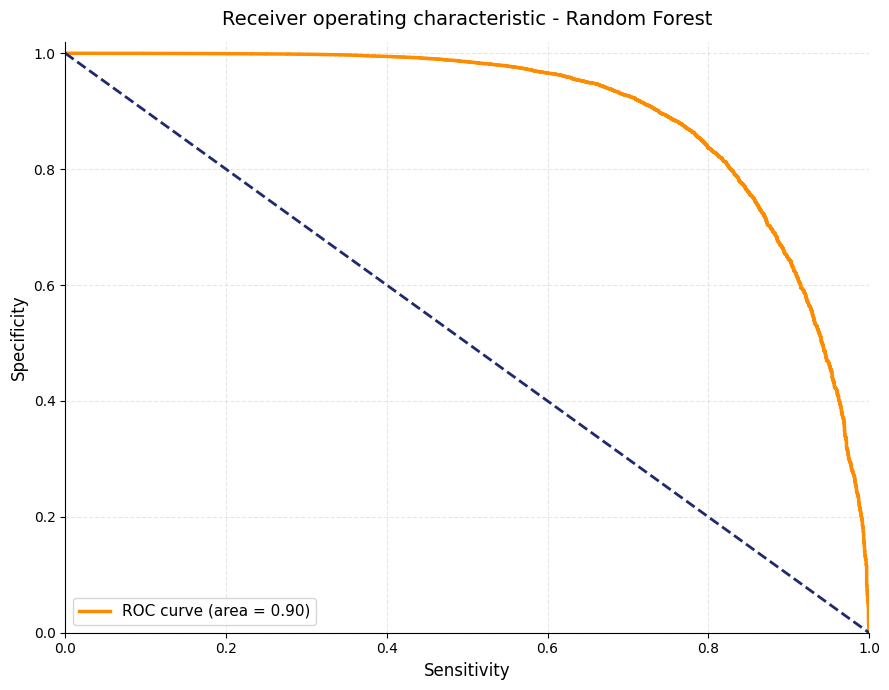

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

test_proba = final_pipeline.predict_proba(X_te_raw)[:, 1]

fpr, tpr, _ = roc_curve(y_te, test_proba)
specificity = 1 - fpr
sensitivity = tpr

auc_score = roc_auc_score(y_te, test_proba)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(sensitivity, specificity, color='#FF8C00', linewidth=2.5,
        label=f'ROC curve (area = {auc_score:.2f})')
ax.plot([0, 1], [1, 0], color='#1F2A6E', linestyle='--', linewidth=2)

ax.set_xlabel('Sensitivity', fontsize=12)
ax.set_ylabel('Specificity', fontsize=12)
ax.set_title('Receiver operating characteristic - Random Forest', fontsize=14, pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()